In [181]:
import numpy as np
import matplotlib.pyplot as plt

In [183]:
J = 5 * 10**(-3) * 1.60217663 * 10**(-19) #5meV
dt = 1 * 10**(-14) #1ps
Time = 1 * 10**(-12) #100ps

hbar = 1.054571817 * 10**(-34)


NSteps = int(Time/dt)

In [185]:
H = np.array([
    [1,  1],
    [1, -1]
], dtype=complex)*J

psi0 = np.array([1, 0], dtype=complex)
psi0 /= np.linalg.norm(psi0)

In [187]:
psi_prev = psi0.copy()
psi_curr = psi0 - 1j/hbar * dt * (H @ psi0)

psi_curr /= np.linalg.norm(psi_curr)

times = [0.0, dt]
states = [psi_prev.copy(), psi_curr.copy()]


for i in range(1, NSteps):
    psi_next = psi_prev - 2j/hbar * dt * (H @ psi_curr)
    #print(psi_next)

    # normalization (H is hermitian but its discretization might be not!)
    psi_next /= np.linalg.norm(psi_next)

    psi_prev = psi_curr
    psi_curr = psi_next

    times.append((i + 1) * dt)
    states.append(psi_curr.copy())
times = np.array(times)

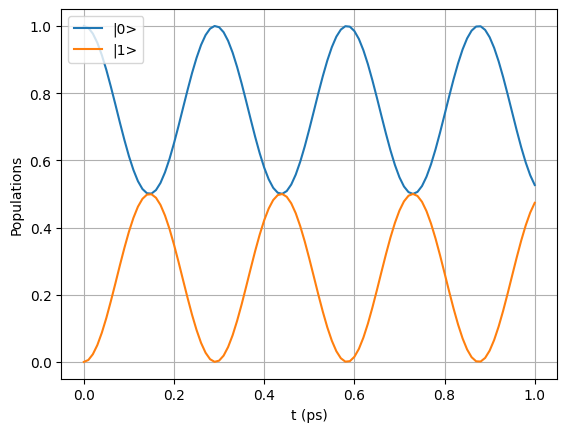

In [189]:
# ----------------------------
# Populations
# ----------------------------
states = np.array(states)
pop_0 = np.abs(states[:, 0])**2
pop_1 = np.abs(states[:, 1])**2

# ----------------------------
# Plot
# ----------------------------
fig, ax = plt.subplots()
ax.plot(times*10**(12), pop_0, label='|0>')
ax.plot(times*10**(12), pop_1, label='|1>')
ax.set_xlabel("t (ps)")
ax.set_ylabel("Populations")
ax.legend()
ax.grid(True)
plt.show()

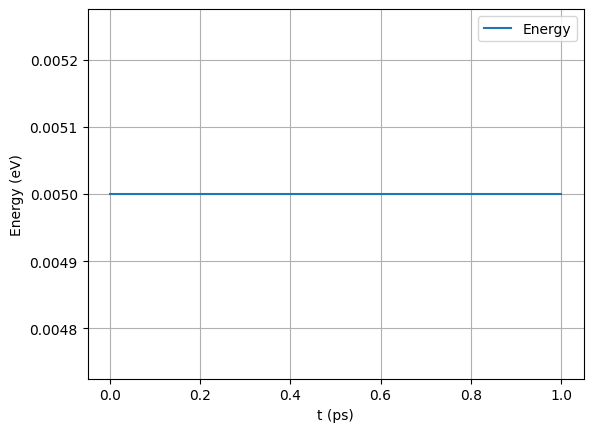

In [179]:
Energies = []
for i in range(0, NSteps+1):
    Energies.append((np.conjugate(states[i,:]) @ H @ states[i,:]).real)

Energies = np.array(Energies)

# ----------------------------
# Plot
# ----------------------------
fig, ax = plt.subplots()
ax.plot(times*10**(12), Energies/(1.60217663 * 10**(-19)), label='Energy')
ax.set_xlabel("t (ps)")
ax.set_ylabel("Energy (eV)")
ax.legend()
ax.grid(True)
plt.show()